# Drug Response Model Training

This notebook loads the tensor artifacts created in `Make_tensors.ipynb`, builds configurable train/val/test splits, and trains configurable drug-response models with PyTorch Lightning.

Supported split modes:
- `drug_blind`
- `tumor_blind` (implemented here as cell-line-blind)
- `mixed`

Supported models
- Linear regression
- MLP (Subnetwork setup)

In [1]:
from pathlib import Path

SPLIT_MODE = "drug_blind"  # one of {"drug_blind", "tumor_blind", "mixed"}
SPLIT_FRACTIONS = {"train": 0.8, "val": 0.1, "test": 0.1}
BATCH_SIZE = 512
RANDOM_SEED = 42
NUM_WORKERS = 0

MODEL_NAME = "mlp"
GENE_BRANCH_HIDDEN_DIMS = (2048, 1024)
DRUG_BRANCH_HIDDEN_DIMS = (512, 128)
COMBINED_HIDDEN_DIMS = (1024, 1024)
TARGET_MODE = "delta"
PREPROCESS_BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
ACCELERATOR = "auto"
DEVICES = 1
PRECISION = "32-true"

PLOT_TEST_SAMPLE_COUNT = 50
PLOT_TEST_SAMPLE_STRATEGY = "seeded_random"
PLOT_RANDOM_SEED = RANDOM_SEED
EMBEDDING_METHOD = "pca"
N_EMBEDDING_COMPONENTS = 2

TENSOR_ARTIFACTS_DIR = Path("data/Tahoe100M_tensor_artifacts_L1000")
LIGHTNING_OUTPUT_DIR = Path("artifacts/lightning/linear_regression")

print(
    {
        "SPLIT_MODE": SPLIT_MODE,
        "SPLIT_FRACTIONS": SPLIT_FRACTIONS,
        "BATCH_SIZE": BATCH_SIZE,
        "RANDOM_SEED": RANDOM_SEED,
        "NUM_WORKERS": NUM_WORKERS,
        "MODEL_NAME": MODEL_NAME,
        "GENE_BRANCH_HIDDEN_DIMS": GENE_BRANCH_HIDDEN_DIMS,
        "DRUG_BRANCH_HIDDEN_DIMS": DRUG_BRANCH_HIDDEN_DIMS,
        "COMBINED_HIDDEN_DIMS": COMBINED_HIDDEN_DIMS,
        "TARGET_MODE": TARGET_MODE,
        "PREPROCESS_BATCH_SIZE": PREPROCESS_BATCH_SIZE,
        "LEARNING_RATE": LEARNING_RATE,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "MAX_EPOCHS": MAX_EPOCHS,
        "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
        "ACCELERATOR": ACCELERATOR,
        "DEVICES": DEVICES,
        "PRECISION": PRECISION,
        "PLOT_TEST_SAMPLE_COUNT": PLOT_TEST_SAMPLE_COUNT,
        "PLOT_TEST_SAMPLE_STRATEGY": PLOT_TEST_SAMPLE_STRATEGY,
        "PLOT_RANDOM_SEED": PLOT_RANDOM_SEED,
        "EMBEDDING_METHOD": EMBEDDING_METHOD,
        "N_EMBEDDING_COMPONENTS": N_EMBEDDING_COMPONENTS,
        "tumor_blind_behavior": "cell_line_blind",
        "model_family": "registry_backed",
    }
)


{'SPLIT_MODE': 'drug_blind', 'SPLIT_FRACTIONS': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'BATCH_SIZE': 512, 'RANDOM_SEED': 42, 'NUM_WORKERS': 0, 'MODEL_NAME': 'mlp', 'GENE_BRANCH_HIDDEN_DIMS': (2048, 1024), 'DRUG_BRANCH_HIDDEN_DIMS': (512, 128), 'COMBINED_HIDDEN_DIMS': (1024, 1024), 'TARGET_MODE': 'delta', 'PREPROCESS_BATCH_SIZE': 1024, 'LEARNING_RATE': 0.001, 'WEIGHT_DECAY': 0.0001, 'MAX_EPOCHS': 50, 'EARLY_STOPPING_PATIENCE': 5, 'ACCELERATOR': 'auto', 'DEVICES': 1, 'PRECISION': '32-true', 'PLOT_TEST_SAMPLE_COUNT': 50, 'PLOT_TEST_SAMPLE_STRATEGY': 'seeded_random', 'PLOT_RANDOM_SEED': 42, 'EMBEDDING_METHOD': 'pca', 'N_EMBEDDING_COMPONENTS': 2, 'tumor_blind_behavior': 'cell_line_blind', 'model_family': 'registry_backed'}


## Imports and Helpers


In [2]:
import math
import sys
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torch.utils.data import DataLoader

for candidate_root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate_root / "pyproject.toml").exists() and (candidate_root / "Machine_Learning" / "ml_pipeline").exists():
        candidate_root_str = str(candidate_root)
        if candidate_root_str not in sys.path:
            sys.path.insert(0, candidate_root_str)
        break
else:
    raise ModuleNotFoundError(
        "Could not resolve the project root needed to import Machine_Learning.ml_pipeline."
    )

from Machine_Learning.ml_pipeline.data import DrugResponseDataModule, TrainingPreprocessor, TreatmentExampleDataset
from Machine_Learning.ml_pipeline.models import MODEL_REGISTRY, build_model
from Machine_Learning.ml_pipeline.utils import (
    SPLIT_NAMES,
    assign_group_blind_splits,
    assign_mixed_split,
    build_loss_history_table,
    build_overlap_diagnostics,
    build_prediction_pair_embedding,
    build_project_path,
    build_split_summary,
    compute_condition_retrieval,
    compute_null_baselines_from_loaders,
    count_trainable_parameters,
    estimate_adamw_memory_gb,
    evaluate_model_on_loader,
    load_cached_cell_line_metadata,
    load_lightning_metrics_table,
    move_batch_to_device,
    resolve_project_path,
    resolve_retrieval_label_column,
    resolve_target_gene_indices,
    sample_prediction_details,
    write_performance_metrics,
    validate_plot_config,
    validate_split_assignments,
    validate_split_config,
    validate_training_config,
)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")


## Load Tensors and Supporting Metadata


In [3]:
validate_split_config(SPLIT_MODE, SPLIT_FRACTIONS)
validate_training_config(
    TARGET_MODE,
    PREPROCESS_BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    MAX_EPOCHS,
    EARLY_STOPPING_PATIENCE,
)
validate_plot_config(
    PLOT_TEST_SAMPLE_COUNT,
    PLOT_TEST_SAMPLE_STRATEGY,
    EMBEDDING_METHOD,
    N_EMBEDDING_COMPONENTS,
)
if MODEL_NAME not in MODEL_REGISTRY:
    available_model_names = ", ".join(sorted(MODEL_REGISTRY))
    raise ValueError(f"Unsupported MODEL_NAME: {MODEL_NAME}. Available models: {available_model_names}")

tensor_artifacts_dir = resolve_project_path(TENSOR_ARTIFACTS_DIR)
dmso_bundle = torch.load(tensor_artifacts_dir / "dmso_baselines.pt", map_location="cpu")
treatment_bundle = torch.load(tensor_artifacts_dir / "treatment_expressions.pt", map_location="cpu")
fingerprint_bundle = torch.load(tensor_artifacts_dir / "morgan_fingerprints.pt", map_location="cpu")

input_gene_ids = [str(gene_id) for gene_id in dmso_bundle["gene_ids"]]
target_gene_ids = [str(gene_id) for gene_id in treatment_bundle["gene_ids"]]
target_gene_indices = resolve_target_gene_indices(input_gene_ids, target_gene_ids)

treatment_feature_space = str(treatment_bundle.get("feature_space", "unknown"))
requested_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("requested_landmark_gene_ids", target_gene_ids)
]
available_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("available_landmark_gene_ids", target_gene_ids)
]
missing_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("missing_landmark_gene_ids", [])
]

if available_landmark_gene_ids and target_gene_ids != available_landmark_gene_ids:
    raise ValueError("Treatment target gene_ids do not match available_landmark_gene_ids metadata.")
if len(target_gene_indices) != len(target_gene_ids):
    raise ValueError("Resolved target gene indices do not match the saved treatment target width.")

cell_line_metadata_df, cell_line_metadata_arrow_path = load_cached_cell_line_metadata()
tensor_cell_lines = set(dmso_bundle["cell_lines"])
matched_cell_line_metadata_df = cell_line_metadata_df.loc[
    cell_line_metadata_df["cell_line"].isin(tensor_cell_lines)
].copy()
missing_cell_line_metadata = sorted(tensor_cell_lines - set(matched_cell_line_metadata_df["cell_line"]))
if missing_cell_line_metadata:
    raise ValueError(f"Missing cell-line metadata for: {missing_cell_line_metadata}")

if matched_cell_line_metadata_df["cell_line"].duplicated().any():
    raise ValueError("cell_line metadata must be unique after deduplication.")

examples_df = pd.DataFrame(
    {
        "condition_key": treatment_bundle["condition_keys"],
        "cell_line": treatment_bundle["cell_lines"],
        "file_name": treatment_bundle["file_names"],
        "drug": treatment_bundle["drug_names"],
        "concentration": treatment_bundle["concentrations"].cpu().numpy().astype(np.float32),
        "concentration_unit": treatment_bundle["concentration_units"],
        "target_index": np.arange(len(treatment_bundle["condition_keys"]), dtype=np.int64),
    }
)
examples_df["baseline_index"] = examples_df["cell_line"].map(dmso_bundle["cell_line_to_index"])
examples_df["fingerprint_index"] = examples_df["drug"].map(fingerprint_bundle["drug_to_index"])

if examples_df["condition_key"].duplicated().any():
    raise ValueError("condition_key values must be unique in the treatment bundle.")
if examples_df["baseline_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a DMSO baseline index.")
if examples_df["fingerprint_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a Morgan fingerprint index.")

examples_df = examples_df.merge(
    matched_cell_line_metadata_df,
    on="cell_line",
    how="left",
    validate="many_to_one",
)
if examples_df[["cell_name", "organ"]].isna().any().any():
    raise ValueError("Some treatment rows do not resolve to cell-line metadata.")

examples_df[["baseline_index", "fingerprint_index", "target_index"]] = examples_df[[
    "baseline_index",
    "fingerprint_index",
    "target_index",
]].astype(int)

tensor_summary_df = pd.DataFrame(
    [
        {
            "bundle": "dmso_baselines",
            "rows": int(dmso_bundle["expressions"].shape[0]),
            "cols": int(dmso_bundle["expressions"].shape[1]),
            "feature_space": "full_protein_coding",
        },
        {
            "bundle": "treatment_expressions",
            "rows": int(treatment_bundle["expressions"].shape[0]),
            "cols": int(treatment_bundle["expressions"].shape[1]),
            "feature_space": treatment_feature_space,
        },
        {
            "bundle": "morgan_fingerprints",
            "rows": int(fingerprint_bundle["fingerprints"].shape[0]),
            "cols": int(fingerprint_bundle["fingerprints"].shape[1]),
            "feature_space": "morgan_radius2_bits2048",
        },
    ]
)
target_space_summary_df = pd.DataFrame(
    [
        {"metric": "input_gene_count", "value": len(input_gene_ids)},
        {"metric": "target_gene_count", "value": len(target_gene_ids)},
        {"metric": "requested_landmark_gene_count", "value": len(requested_landmark_gene_ids)},
        {"metric": "available_landmark_gene_count", "value": len(available_landmark_gene_ids)},
        {"metric": "missing_landmark_gene_count", "value": len(missing_landmark_gene_ids)},
        {"metric": "treatment_feature_space", "value": treatment_feature_space},
    ]
)
metadata_summary_df = pd.DataFrame(
    [
        {
            "tensor_artifacts_dir": str(tensor_artifacts_dir),
            "cell_line_metadata_arrow_path": str(cell_line_metadata_arrow_path),
            "n_examples": int(len(examples_df)),
            "n_unique_drugs": int(examples_df["drug"].nunique()),
            "n_unique_cell_lines": int(examples_df["cell_line"].nunique()),
            "n_unique_organs": int(examples_df["organ"].nunique()),
        }
    ]
)
missing_landmark_summary_df = pd.DataFrame({"missing_landmark_gene_id": missing_landmark_gene_ids})

print(
    f"Loaded {len(examples_df)} treatment examples with {len(input_gene_ids)} input genes and {len(target_gene_ids)} target genes in {treatment_feature_space}."
)
display(tensor_summary_df)
display(target_space_summary_df)
display(metadata_summary_df)
if not missing_landmark_summary_df.empty:
    display(missing_landmark_summary_df)
display(examples_df.head())


Loaded 26696 treatment examples with 20061 input genes and 977 target genes in l1000_landmark_intersection.


,bundle,rows,cols,feature_space
0,dmso_baselines,24,20061,full_protein_coding
1,treatment_expressions,26696,977,l1000_landmark_intersection
2,morgan_fingerprints,377,2048,morgan_radius2_bits2048


,metric,value
0,input_gene_count,20061
1,target_gene_count,977
2,requested_landmark_gene_count,978
3,available_landmark_gene_count,977
4,missing_landmark_gene_count,1
5,treatment_feature_space,l1000_landmark_intersection


,tensor_artifacts_dir,cell_line_metadata_arrow_path,n_examples,n_unique_drugs,n_unique_cell_lines,n_unique_organs
0,/Users/liamwilson/dl_fin/deep-learning-final-p...,/Users/liamwilson/.cache/huggingface/datasets/...,26696,377,24,10


,missing_landmark_gene_id
0,ENSG00000153113


,condition_key,cell_line,file_name,drug,concentration,concentration_unit,target_index,baseline_index,fingerprint_index,cell_name,organ
0,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.05,uM,0,0,118,A549,Lung
1,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.50,uM,1,0,118,A549,Lung
2,CVCL_0023|||(R)-Verapamil (hydrochloride)|||5|...,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),5.00,uM,2,0,118,A549,Lung
3,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.05,uM,3,0,137,A549,Lung
4,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.50,uM,4,0,137,A549,Lung


## Split Examples and Build DataLoaders


In [4]:
if SPLIT_MODE == "drug_blind":
    split_mode_note = "drug_blind: entire drugs are held out from train."
    split_unit_column = "drug"
    split_assignments = assign_group_blind_splits(
        examples_df,
        group_col="drug",
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )
elif SPLIT_MODE == "tumor_blind":
    split_mode_note = "tumor_blind: this notebook implements cell-line-blind splits rather than Organ-level splits."
    split_unit_column = "cell_line"
    split_assignments = assign_group_blind_splits(
        examples_df,
        group_col="cell_line",
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )
else:
    split_mode_note = "mixed: condition keys are held out, but every drug and cell line remains represented in train."
    split_unit_column = "condition_key"
    split_assignments = assign_mixed_split(
        examples_df,
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )

split_examples_df = examples_df.copy()
split_examples_df["split"] = split_assignments.to_numpy()
validate_split_assignments(split_examples_df, SPLIT_MODE)

split_summary_df = build_split_summary(split_examples_df, SPLIT_FRACTIONS)
split_unit_summary_df = (
    split_examples_df.groupby("split")[split_unit_column]
    .nunique()
    .reindex(SPLIT_NAMES)
    .reset_index(name=f"unique_{split_unit_column}_count")
)
overlap_diagnostics_df = build_overlap_diagnostics(split_examples_df, SPLIT_MODE)

train_examples_df = split_examples_df.loc[split_examples_df["split"] == "train"].reset_index(drop=True)
val_examples_df = split_examples_df.loc[split_examples_df["split"] == "val"].reset_index(drop=True)
test_examples_df = split_examples_df.loc[split_examples_df["split"] == "test"].reset_index(drop=True)
split_sample_counts = {split_name: int((split_examples_df["split"] == split_name).sum()) for split_name in SPLIT_NAMES}

train_dataset = TreatmentExampleDataset(train_examples_df, dmso_bundle, treatment_bundle, fingerprint_bundle)
val_dataset = TreatmentExampleDataset(val_examples_df, dmso_bundle, treatment_bundle, fingerprint_bundle)
test_dataset = TreatmentExampleDataset(test_examples_df, dmso_bundle, treatment_bundle, fingerprint_bundle)

train_generator = torch.Generator().manual_seed(RANDOM_SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=False,
    generator=train_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
)

print(
    f"Using {SPLIT_MODE} split. {split_mode_note} Sample counts -> train: {split_sample_counts['train']}, val: {split_sample_counts['val']}, test: {split_sample_counts['test']}."
)
display(split_summary_df)
display(split_unit_summary_df)
display(overlap_diagnostics_df)


Using drug_blind split. drug_blind: entire drugs are held out from train. Sample counts -> train: 21368, val: 2664, test: 2664.


,split,target_rows,row_count,requested_fraction,realized_fraction,unique_drugs,unique_cell_lines,unique_organs
0,train,21356,21368,0.8,0.80042,303,24,10
1,val,2670,2664,0.1,0.09979,37,24,10
2,test,2670,2664,0.1,0.09979,37,24,10


,split,unique_drug_count
0,train,303
1,val,37
2,test,37


,entity,pair,overlap_count
0,drug,train/val,0
1,drug,train/test,0
2,drug,val/test,0
3,condition_key,train/val,0
4,condition_key,train/test,0
5,condition_key,val/test,0
6,cell_line,train/val,24
7,cell_line,train/test,24
8,cell_line,val/test,24


## Inspect One Batch


In [5]:
batch_examples = {
    "train": next(iter(train_loader)),
    "val": next(iter(val_loader)),
    "test": next(iter(test_loader)),
}

batch_summary_rows = []
for split_name, batch in batch_examples.items():
    split_source_df = split_examples_df.loc[split_examples_df["split"] == split_name].set_index("condition_key")
    first_condition_key = batch["condition_key"][0]
    source_row = split_source_df.loc[first_condition_key]

    if batch["drug"][0] != source_row["drug"] or batch["cell_line"][0] != source_row["cell_line"]:
        raise ValueError("Batch metadata does not align with the split source table.")

    if batch["baseline_expression"].shape[0] > BATCH_SIZE:
        raise ValueError("A batch exceeded the configured batch size.")
    if batch["baseline_expression"].shape[1] != len(dmso_bundle["gene_ids"]):
        raise ValueError("Baseline expression width does not match the gene space.")
    if batch["drug_fingerprint"].shape[1] != fingerprint_bundle["fingerprints"].shape[1]:
        raise ValueError("Drug fingerprint width does not match the saved Morgan tensor.")
    if batch["target_expression"].shape[1] != len(treatment_bundle["gene_ids"]):
        raise ValueError("Target expression width does not match the gene space.")

    batch_summary_rows.append(
        {
            "split": split_name,
            "batch_rows": int(batch["baseline_expression"].shape[0]),
            "baseline_shape": tuple(batch["baseline_expression"].shape),
            "fingerprint_shape": tuple(batch["drug_fingerprint"].shape),
            "concentration_shape": tuple(batch["concentration"].shape),
            "target_shape": tuple(batch["target_expression"].shape),
            "first_condition_key": first_condition_key,
            "first_cell_line": batch["cell_line"][0],
            "first_drug": batch["drug"][0],
        }
    )

batch_summary_df = pd.DataFrame(batch_summary_rows)
display(batch_summary_df)


,split,batch_rows,baseline_shape,fingerprint_shape,concentration_shape,target_shape,first_condition_key,first_cell_line,first_drug
0,train,512,"(512, 20061)","(512, 2048)","(512,)","(512, 977)",CVCL_0359|||Canagliflozin|||0.05|||uM,CVCL_0359,Canagliflozin
1,val,512,"(512, 20061)","(512, 2048)","(512,)","(512, 977)",CVCL_0023|||Adenine|||0.05|||uM,CVCL_0023,Adenine
2,test,512,"(512, 20061)","(512, 2048)","(512,)","(512, 977)",CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,(S)-Crizotinib


## Fit the Training Preprocessor


In [6]:
training_preprocessor = TrainingPreprocessor(
    train_examples_df=train_examples_df,
    dmso_bundle=dmso_bundle,
    treatment_bundle=treatment_bundle,
    fingerprint_bundle=fingerprint_bundle,
    target_gene_indices=target_gene_indices,
    target_mode=TARGET_MODE,
    batch_size=PREPROCESS_BATCH_SIZE,
).fit()

preprocessor_summary_df = training_preprocessor.summary_frame()
display(preprocessor_summary_df)


,target_mode,train_examples,input_dim,input_gene_dim,target_gene_dim,fingerprint_dim,dose_log_mean,dose_log_std,baseline_std_min,delta_std_min
0,delta,21368,22110,20061,977,2048,-0.307488,0.816949,0.001,0.198753


## Build the Lightning DataModule and Model


In [7]:
response_data_module = DrugResponseDataModule(
    train_examples_df=train_examples_df,
    val_examples_df=val_examples_df,
    test_examples_df=test_examples_df,
    preprocessor=training_preprocessor,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=RANDOM_SEED,
)
response_data_module.setup()

input_feature_dim = training_preprocessor.input_dim
target_gene_dim = training_preprocessor.target_gene_dim

model_build_kwargs = {
    "gene_dim": target_gene_dim,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "delta_mean": training_preprocessor.delta_mean,
    "delta_std": training_preprocessor.delta_std,
}
if MODEL_NAME == "ridge":
    model_build_kwargs["input_dim"] = input_feature_dim
elif MODEL_NAME == "mlp":
    model_build_kwargs.update(
        {
            "input_gene_dim": training_preprocessor.input_gene_dim,
            "drug_feature_dim": training_preprocessor.fingerprint_dim,
            "dose_feature_dim": 1,
            "gene_branch_hidden_dims": GENE_BRANCH_HIDDEN_DIMS,
            "drug_branch_hidden_dims": DRUG_BRANCH_HIDDEN_DIMS,
            "combined_hidden_dims": COMBINED_HIDDEN_DIMS,
        }
    )

response_model = build_model(MODEL_NAME, **model_build_kwargs)

prepared_train_batch = next(iter(response_data_module.train_eval_dataloader()))
if prepared_train_batch["input_features"].shape[1] != input_feature_dim:
    raise ValueError("Prepared input feature width does not match the expected model input dimension.")
if prepared_train_batch["gene_features"].shape[1] != training_preprocessor.input_gene_dim:
    raise ValueError("Prepared gene feature width does not match the normalized DMSO input dimension.")
if prepared_train_batch["drug_features"].shape[1] != training_preprocessor.fingerprint_dim:
    raise ValueError("Prepared drug feature width does not match the fingerprint dimension.")
if prepared_train_batch["dose_feature"].ndim != 2 or prepared_train_batch["dose_feature"].shape[1] != 1:
    raise ValueError("Prepared dose feature must be a 2D tensor with a single feature column.")
if prepared_train_batch["target_delta"].shape[1] != target_gene_dim:
    raise ValueError("Prepared target delta width does not match the target gene space.")
reconstructed_target_expression = prepared_train_batch["baseline_expression"] + prepared_train_batch["target_delta"]
if reconstructed_target_expression.shape != prepared_train_batch["baseline_expression"].shape:
    raise ValueError("Reconstructed treated expression has an unexpected shape.")

model_summary_df = pd.DataFrame(
    [
        {
            "model_family": MODEL_NAME,
            "input_feature_dim": int(input_feature_dim),
            "input_gene_dim": int(training_preprocessor.input_gene_dim),
            "target_gene_dim": int(target_gene_dim),
            "output_dim": int(response_model.output_dim),
            "trainable_parameters": count_trainable_parameters(response_model),
            "estimated_adamw_memory_gb": estimate_adamw_memory_gb(response_model),
            "gene_branch_hidden_dims": GENE_BRANCH_HIDDEN_DIMS if MODEL_NAME == "mlp" else None,
            "drug_branch_hidden_dims": DRUG_BRANCH_HIDDEN_DIMS if MODEL_NAME == "mlp" else None,
            "combined_hidden_dims": COMBINED_HIDDEN_DIMS if MODEL_NAME == "mlp" else None,
            "treatment_feature_space": treatment_feature_space,
        }
    ]
)
prepared_batch_summary_df = pd.DataFrame(
    [
        {
            "split": "train",
            "input_shape": tuple(prepared_train_batch["input_features"].shape),
            "gene_feature_shape": tuple(prepared_train_batch["gene_features"].shape),
            "drug_feature_shape": tuple(prepared_train_batch["drug_features"].shape),
            "dose_feature_shape": tuple(prepared_train_batch["dose_feature"].shape),
            "baseline_shape": tuple(prepared_train_batch["baseline_expression"].shape),
            "target_delta_shape": tuple(prepared_train_batch["target_delta"].shape),
            "concentration_shape": tuple(prepared_train_batch["concentration"].shape),
        }
    ]
)

print(
    f"{MODEL_NAME} model creates {count_trainable_parameters(response_model):,} trainable parameters with input width {input_feature_dim} and target width {target_gene_dim}."
)

display(model_summary_df)
display(prepared_batch_summary_df)


mlp model creates 47,532,625 trainable parameters with input width 22110 and target width 977.


,model_family,input_feature_dim,input_gene_dim,target_gene_dim,output_dim,trainable_parameters,estimated_adamw_memory_gb,gene_branch_hidden_dims,drug_branch_hidden_dims,combined_hidden_dims,treatment_feature_space
0,mlp,22110,20061,977,977,47532625,0.708291,"(2048, 1024)","(512, 128)","(1024, 1024)",l1000_landmark_intersection


,split,input_shape,gene_feature_shape,drug_feature_shape,dose_feature_shape,baseline_shape,target_delta_shape,concentration_shape
0,train,"(512, 22110)","(512, 20061)","(512, 2048)","(512, 1)","(512, 977)","(512, 977)","(512,)"


## Train with PyTorch Lightning


In [8]:
L.seed_everything(RANDOM_SEED, workers=True)

lightning_output_dir = build_project_path(LIGHTNING_OUTPUT_DIR)
lightning_output_dir.mkdir(parents=True, exist_ok=True)
run_name = f"{SPLIT_MODE}_{MODEL_NAME}_{TARGET_MODE}"

csv_logger = CSVLogger(save_dir=str(lightning_output_dir), name=run_name)
checkpoint_dir = lightning_output_dir / run_name / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(checkpoint_dir),
    filename="epoch={epoch:02d}-val_loss={val_loss:.6f}",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)
early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=EARLY_STOPPING_PATIENCE,
)

trainer = L.Trainer(
    accelerator=ACCELERATOR,
    devices=DEVICES,
    precision=PRECISION,
    max_epochs=MAX_EPOCHS,
    logger=csv_logger,
    callbacks=[checkpoint_callback, early_stopping_callback],
    log_every_n_steps=max(1, math.ceil(len(train_examples_df) / BATCH_SIZE / 10)),
    deterministic=False,
)

trainer.fit(response_model, datamodule=response_data_module)
validation_results = trainer.validate(response_model, datamodule=response_data_module, ckpt_path="best", verbose=False)
test_results = trainer.test(response_model, datamodule=response_data_module, ckpt_path="best", verbose=False)

best_model_path = checkpoint_callback.best_model_path
if not best_model_path:
    raise ValueError("Lightning did not produce a best checkpoint path.")

best_checkpoint_state = torch.load(best_model_path, map_location="cpu")
response_model.load_state_dict(best_checkpoint_state["state_dict"])
metrics_csv_path = Path(csv_logger.log_dir) / "metrics.csv"
training_run_summary_path = Path(csv_logger.log_dir) / "training_run_summary.json"

training_run_summary_df = pd.DataFrame(
    [
        {
            "best_model_path": str(best_model_path),
            "metrics_csv_path": str(metrics_csv_path),
            "best_val_loss": float(checkpoint_callback.best_model_score.item()),
            "logger_dir": str(csv_logger.log_dir),
            "current_epoch": int(trainer.current_epoch),
            "run_name": run_name,
        }
    ]
)
training_run_summary_path.write_text(training_run_summary_df.to_json(orient="records", indent=2))

display(training_run_summary_df)
display(pd.DataFrame(validation_results))
display(pd.DataFrame(test_results))


Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/linear_regression/drug_blind_mlp_delta/checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gene_network     │ Sequential │ 43.2 M │ train │     0 │
│ 1 │ drug_network     │ Sequential │  1.1 M │ train │     0 │
│ 2 │ combined_network │ Sequential │  3.2 M │ train │     0 │
└───┴──────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 47.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 47.5 M                                                                                               
Total estimated model params size (MB): 190                                                                        
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities
/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

...

Restoring states from the checkpoint path at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/linear_regression/drug_blind_mlp_delta/checkpoints/epoch=epoch=00-val_loss=val_loss=591.767273.ckpt
Loaded model weights from the checkpoint at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/linear_regression/drug_blind_mlp_delta/checkpoints/epoch=epoch=00-val_loss=val_loss=591.767273.ckpt


Restoring states from the checkpoint path at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/linear_regression/drug_blind_mlp_delta/checkpoints/epoch=epoch=00-val_loss=val_loss=591.767273.ckpt
Loaded model weights from the checkpoint at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/linear_regression/drug_blind_mlp_delta/checkpoints/epoch=epoch=00-val_loss=val_loss=591.767273.ckpt
/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


,best_model_path,metrics_csv_path,best_val_loss,logger_dir,current_epoch,run_name
0,/Users/liamwilson/dl_fin/deep-learning-final-p...,/Users/liamwilson/dl_fin/deep-learning-final-p...,591.767273,/Users/liamwilson/dl_fin/deep-learning-final-p...,6,drug_blind_mlp_delta


,val_loss,val_delta_mse,val_delta_mae,val_treated_cosine,val_delta_cosine,val_delta_pearson
0,591.767273,591.767273,8.627108,0.981334,0.314867,0.328138


,test_loss,test_delta_mse,test_delta_mae,test_treated_cosine,test_delta_cosine,test_delta_pearson
0,603.528931,603.528931,8.254682,0.984177,0.335266,0.34858


In [9]:
try:
    from torchinfo import summary
except ImportError:
    print("torchinfo is not installed in this environment; skipping the detailed model summary cell.")
else:
    model_info = summary(
        response_model,
        input_data=prepared_train_batch["input_features"][:1],
        col_names=["input_size", "output_size", "num_params", "trainable"],
    )
    print(model_info)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MLPDrugResponseModule                    [1, 22110]                [1, 977]                  --                        True
├─Sequential: 1-1                        [1, 20061]                [1, 1024]                 --                        True
│    └─Linear: 2-1                       [1, 20061]                [1, 2048]                 41,086,976                True
│    └─ReLU: 2-2                         [1, 2048]                 [1, 2048]                 --                        --
│    └─Linear: 2-3                       [1, 2048]                 [1, 1024]                 2,098,176                 True
├─Sequential: 1-2                        [1, 2048]                 [1, 128]                  --                        True
│    └─Linear: 2-4                       [1, 2048]                 [1, 512]                  1,049,088                 True
│    

## Evaluate the Best Checkpoint


In [10]:
evaluation_rows = []
inspection_tables = {}
prediction_detail_tables = {}
prediction_delta_arrays = {}
evaluation_loaders = {
    "train": response_data_module.train_eval_dataloader(),
    "val": response_data_module.val_dataloader(),
    "test": response_data_module.test_dataloader(),
}

model_device = next(response_model.parameters()).device
retrieval_label_column = resolve_retrieval_label_column(SPLIT_MODE)

response_model.eval()
for split_name, loader in evaluation_loaders.items():
    metrics_row, inspection_df, prediction_details_df = evaluate_model_on_loader(
        model=response_model,
        loader=loader,
        split_name=split_name,
        gene_ids=target_gene_ids,
    )
    evaluation_rows.append(metrics_row)
    inspection_tables[split_name] = inspection_df
    prediction_detail_tables[split_name] = prediction_details_df

    predicted_delta_chunks = []
    target_delta_chunks = []
    label_chunks = []
    with torch.no_grad():
        for batch in loader:
            batch_on_device = move_batch_to_device(batch, model_device)
            predicted_delta_chunks.append(
                response_model(batch_on_device).detach().cpu().numpy()
            )
            target_delta_chunks.append(
                batch_on_device["target_delta"].detach().cpu().numpy()
            )
            label_values = batch[retrieval_label_column]
            if isinstance(label_values, (list, tuple)):
                label_chunks.extend(str(value) for value in label_values)
            else:
                label_chunks.extend(str(value) for value in list(label_values))
    prediction_delta_arrays[split_name] = (
        np.concatenate(predicted_delta_chunks, axis=0) if predicted_delta_chunks else np.zeros((0, len(target_gene_ids)), dtype=np.float32),
        np.concatenate(target_delta_chunks, axis=0) if target_delta_chunks else np.zeros((0, len(target_gene_ids)), dtype=np.float32),
        np.asarray(label_chunks, dtype=object),
    )

evaluation_summary_df = pd.DataFrame(evaluation_rows)
evaluation_summary_df.insert(0, "predictor", "model")

null_baseline_rows = compute_null_baselines_from_loaders(
    train_loader=evaluation_loaders["train"],
    val_loader=evaluation_loaders["val"],
    test_loader=evaluation_loaders["test"],
    gene_ids=target_gene_ids,
)
null_baselines_df = pd.DataFrame(null_baseline_rows)
evaluation_summary_df = pd.concat(
    [null_baselines_df, evaluation_summary_df],
    ignore_index=True,
)

retrieval_rows = []
for split_name, (predicted_delta_np, target_delta_np, labels) in prediction_delta_arrays.items():
    retrieval_rows.append(
        {
            "split": split_name,
            "label_column": retrieval_label_column,
            **compute_condition_retrieval(predicted_delta_np, target_delta_np, labels),
        }
    )
retrieval_summary_df = pd.DataFrame(retrieval_rows)

test_prediction_details_df = prediction_detail_tables["test"].copy()
print(f"Evaluated best checkpoint from {best_model_path}")
display(evaluation_summary_df)
display(retrieval_summary_df)
display(inspection_tables["test"])
display(test_prediction_details_df.head())


Evaluated best checkpoint from /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/linear_regression/drug_blind_mlp_delta/checkpoints/epoch=epoch=00-val_loss=val_loss=591.767273.ckpt


,split,n_samples,delta_mse,delta_mae,treated_cosine,mann_whitney_u_median,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction,top50_deg_match_count_mean,...,delta_cosine_mean,delta_pearson_mean,delta_pearson_median,delta_spearman_mean,delta_spearman_median,delta_r2_vs_zero_mean,delta_r2_vs_zero_median,magnitude_ratio_mean,predictor,cell_line_mean_fell_back
0,train,21368,802.178046,9.289790,0.972141,487407.5,0.199551,0.038351,0.475711,1.788562,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,zero,NaN
1,train,21368,762.666034,9.179876,0.972944,479802.0,0.209661,0.050914,0.502153,18.355344,...,0.280618,0.286893,0.332505,0.235636,0.252598,0.048607,0.082896,0.342442,global_mean,NaN
2,train,21368,699.501272,8.646281,0.976723,487027.5,0.203281,0.040975,0.483995,24.586438,...,0.408743,0.419708,0.502781,0.316806,0.330563,0.153406,0.200391,0.439952,cell_line_mean,False
3,val,2664,633.248447,8.753595,0.978583,477622.5,0.226869,0.075690,0.545045,1.715465,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,zero,NaN
4,val,2664,608.932248,8.744977,0.979743,470136.0,0.224305,0.070319,0.537913,17.888889,...,0.269923,0.284061,0.318202,0.222805,0.235918,0.049908,0.076049,0.355225,global_mean,NaN
5,val,2664,578.620487,8.222536,0.982874,476612.0,0.235087,0.081393,0.555556,23.904655,...,0.379045,0.391400,0.475738,0.311479,0.325762,0.132233,0.183641,0.459583,cell_line_mean,False
6,test,2664,643.457201,8.386231,0.981084,479521.0,0.237922,0.082491,0.550676,1.715090,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,zero,NaN
7,test,2664,615.807353,8.364726,0.982694,472059.0,0.246016,0.089449,0.558183,18.415916,...,0.294013,0.308106,0.361967,0.229974,0.260359,0.069917,0.098087,0.363108,global_mean,NaN
8,test,2664,592.977616,7.846832,0.985644,479289.5,0.238852,0.083661,0.560060,24.641141,...,0.399764,0.411573,0.524080,0.319630,0.346070,0.166891,0.230634,0.463949,cell_line_mean,False
9,train,21368,720.898540,9.031557,0.974890,482095.0,0.211061,0.051038,0.501919,19.984978,...,0.337666,0.345683,0.383253,0.233831,0.232732,0.105034,0.119366,0.376157,model,NaN


,split,label_column,n_samples,n_labels,mean_rank,median_rank,top1,chance_top1,top5,chance_top5
0,train,drug,21368,303,151.457413,151.0,0.003370,0.003300,0.016941,0.016502
1,val,drug,2664,37,19.000375,19.0,0.027402,0.027027,0.135135,0.135135
2,test,drug,2664,37,18.992492,19.0,0.027027,0.027027,0.135135,0.135135


,split,condition_key,cell_line,drug,concentration,sample_delta_mse,sample_treated_cosine,sample_mann_whitney_u,sample_mann_whitney_pvalue,sample_top50_deg_match_count,...,pred_ENSG00000000003,target_ENSG00000000003,pred_ENSG00000000457,target_ENSG00000000457,pred_ENSG00000002330,target_ENSG00000002330,pred_ENSG00000002549,target_ENSG00000002549,pred_ENSG00000002919,target_ENSG00000002919
0,test,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,(S)-Crizotinib,0.05,293.637177,0.970783,499836.0,0.070299,24.0,...,3.361986,4.257095,4.009293,2.587646,3.630955,3.923205,30.312174,23.706177,4.853393,3.255426
1,test,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,(S)-Crizotinib,0.50,82.625679,0.991812,495430.0,0.145210,21.0,...,3.361941,2.905129,4.010147,3.449841,3.631765,3.540627,30.311937,28.960508,4.853339,5.356332
2,test,CVCL_0023|||(S)-Crizotinib|||5|||uM,CVCL_0023,(S)-Crizotinib,5.00,112.182304,0.988066,479921.0,0.831338,20.0,...,3.361859,3.122290,4.011236,3.295750,3.632419,3.989592,30.310822,26.366001,4.853364,4.336514


,split,dataset_index,condition_key,cell_line,cell_name,organ,drug,concentration,concentration_unit,delta_mse,...,mann_whitney_u,mann_whitney_pvalue,top50_deg_match_count,top50_deg_match_fraction,signed_ndcg_at_50,delta_cosine,delta_pearson,delta_spearman,delta_r2_vs_zero,magnitude_ratio
0,test,0,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,0.05,uM,293.637177,...,499836.0,0.070299,24.0,0.48,0.713146,0.651856,0.663772,0.316504,0.331458,0.346147
1,test,1,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,0.50,uM,82.625679,...,495430.0,0.145210,21.0,0.42,0.670681,0.690493,0.700725,0.329278,0.465356,0.583606
2,test,2,CVCL_0023|||(S)-Crizotinib|||5|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,5.00,uM,112.182304,...,479921.0,0.831338,20.0,0.40,0.739965,0.712828,0.712828,0.290583,0.463557,0.501720
3,test,3,CVCL_0023|||Abiraterone acetate|||0.05|||uM,CVCL_0023,A549,Lung,Abiraterone acetate,0.05,uM,195.983948,...,492464.0,0.222914,26.0,0.52,0.691085,0.695657,0.707584,0.355203,0.397871,0.402284
4,test,4,CVCL_0023|||Abiraterone acetate|||0.5|||uM,CVCL_0023,A549,Lung,Abiraterone acetate,0.50,uM,234.368530,...,465212.0,0.333816,19.0,0.38,0.576603,0.519651,0.524529,0.367999,0.257685,0.408511


## Plot Train and Validation Loss


Loaded Lightning loss history from /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/linear_regression/drug_blind_mlp_delta/version_1/metrics.csv


,epoch,loss,split
0,0,974.852112,train
1,0,591.767273,val
2,1,713.055786,train
3,1,611.068237,val
4,2,644.461365,train
5,2,708.298279,val
6,3,594.969055,train
7,3,743.176392,val
8,4,574.233032,train
9,4,728.974182,val


,split,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction
0,train,0.199551,0.038351,0.475711
1,train,0.209661,0.050914,0.502153
2,train,0.203281,0.040975,0.483995
3,train,0.211061,0.051038,0.501919
4,val,0.226869,0.075690,0.545045
5,val,0.224305,0.070319,0.537913
6,val,0.235087,0.081393,0.555556
7,val,0.227273,0.079647,0.546171


,split,top50_deg_match_count_mean,top50_deg_match_count_median,top50_deg_match_fraction_mean,top50_deg_match_fraction_median,signed_ndcg_at_50_mean,signed_ndcg_at_50_median
0,train,1.788562,2.0,0.035771,0.04,0.000000,0.000000
1,train,18.355344,18.0,0.367107,0.36,0.422683,0.426442
2,train,24.586438,24.0,0.491729,0.48,0.570241,0.601586
3,train,19.984978,20.0,0.399700,0.40,0.492941,0.490655
4,val,1.715465,2.0,0.034309,0.04,0.000000,0.000000
5,val,17.888889,18.0,0.357778,0.36,0.408425,0.404876
6,val,23.904655,24.0,0.478093,0.48,0.546830,0.575362
7,val,19.538664,19.0,0.390773,0.38,0.473828,0.469043


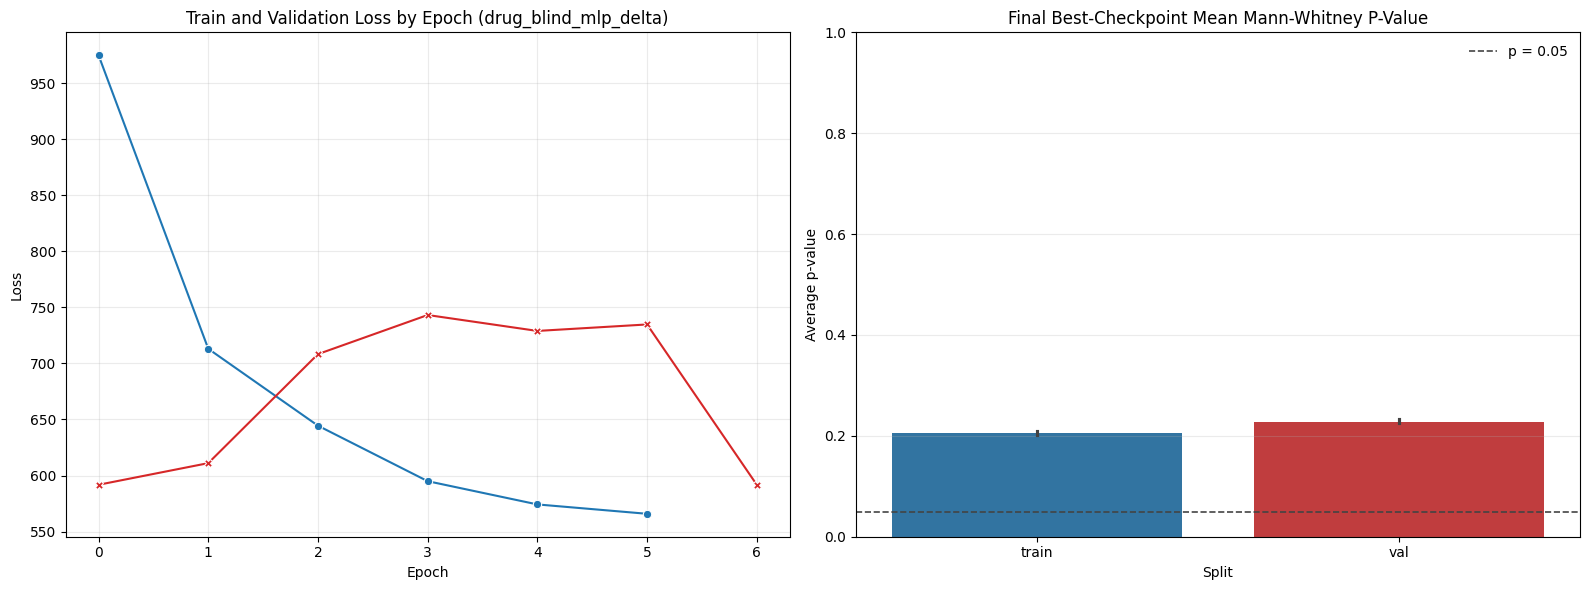

In [11]:
lightning_metrics_df = load_lightning_metrics_table(metrics_csv_path)
loss_history_df = build_loss_history_table(lightning_metrics_df)
train_val_mann_whitney_summary_df = (
    evaluation_summary_df.loc[evaluation_summary_df["split"].isin(["train", "val"])]
    .copy()
    .sort_values("split", key=lambda s: s.map({"train": 0, "val": 1}), ignore_index=True)
)

print(f"Loaded Lightning loss history from {metrics_csv_path}")
display(loss_history_df)
display(
    train_val_mann_whitney_summary_df[
        [
            "split",
            "mann_whitney_pvalue_mean",
            "mann_whitney_pvalue_median",
            "mann_whitney_not_significant_fraction",
        ]
    ]
)
display(
    train_val_mann_whitney_summary_df[
        [
            "split",
            "top50_deg_match_count_mean",
            "top50_deg_match_count_median",
            "top50_deg_match_fraction_mean",
            "top50_deg_match_fraction_median",
            "signed_ndcg_at_50_mean",
            "signed_ndcg_at_50_median",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
loss_ax, pvalue_ax = axes

sns.lineplot(
    data=loss_history_df,
    x="epoch",
    y="loss",
    hue="split",
    style="split",
    markers=True,
    dashes=False,
    palette={"train": "#1f77b4", "val": "#d62728"},
    ax=loss_ax,
)
loss_ax.set_title(f"Train and Validation Loss by Epoch ({run_name})")
loss_ax.set_xlabel("Epoch")
loss_ax.set_ylabel("Loss")
loss_ax.grid(True, alpha=0.25)
legend = loss_ax.get_legend()
if legend is not None:
    legend.remove()

sns.barplot(
    data=train_val_mann_whitney_summary_df,
    x="split",
    y="mann_whitney_pvalue_mean",
    hue="split",
    order=["train", "val"],
    hue_order=["train", "val"],
    palette={"train": "#1f77b4", "val": "#d62728"},
    dodge=False,
    legend=False,
    ax=pvalue_ax,
)
pvalue_ax.axhline(0.05, color="#444444", linestyle="--", linewidth=1.2, label="p = 0.05")
pvalue_ax.set_title("Final Best-Checkpoint Mean Mann-Whitney P-Value")
pvalue_ax.set_xlabel("Split")
pvalue_ax.set_ylabel("Average p-value")
pvalue_ax.set_ylim(0, max(1.0, float(train_val_mann_whitney_summary_df["mann_whitney_pvalue_mean"].max()) * 1.1))
pvalue_ax.grid(True, axis="y", alpha=0.25)
pvalue_ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()


## Plot Predicted vs Actual Test Pairs


Plotted 50 seeded_random test pairs with PCA using the best checkpoint.


,pair_index,condition_key,cell_line,drug,concentration,concentration_unit,treated_mse,delta_mse,treated_cosine,mann_whitney_u,mann_whitney_pvalue,top50_deg_match_count,top50_deg_match_fraction,signed_ndcg_at_50,delta_cosine,delta_pearson,delta_spearman,delta_r2_vs_zero,magnitude_ratio,pair_distance_2d
0,15,CVCL_0131|||Olanzapine|||5|||uM,CVCL_0131,Olanzapine,5.00,uM,3405.335693,3405.335693,0.971349,400798.0,8.686572e-10,20.0,0.40,0.136117,-0.510633,-0.524511,0.073702,-0.496370,0.359491,1603.922241
1,42,CVCL_0480|||Relugolix|||5|||uM,CVCL_0480,Relugolix,5.00,uM,5545.672363,5545.672363,0.990721,370200.0,9.043264e-18,21.0,0.42,0.115053,-0.351405,-0.320697,-0.118992,-0.089652,0.110263,1335.597290
2,26,CVCL_0332|||Omeprazole (sodium)|||5|||uM,CVCL_0332,Omeprazole (sodium),5.00,uM,2134.851562,2134.851562,0.996841,440653.0,3.326301e-03,17.0,0.34,0.152363,-0.427818,-0.452018,0.173049,-0.700438,0.512111,1334.473511
3,14,CVCL_0131|||Bergenin|||5|||uM,CVCL_0131,Bergenin,5.00,uM,1295.058838,1295.058838,0.977996,454965.0,7.374898e-02,20.0,0.40,0.096762,-0.562122,-0.562877,0.066475,-1.359338,0.732219,946.236023
4,41,CVCL_0480|||Darinaparsin|||5|||uM,CVCL_0480,Darinaparsin,5.00,uM,2693.482910,2693.482910,0.975232,378526.0,2.416545e-15,17.0,0.34,0.216195,-0.009808,0.079511,0.032125,-0.026536,0.153386,678.826050
5,32,CVCL_0371|||Everolimus|||5|||uM,CVCL_0371,Everolimus,5.00,uM,792.944763,792.944702,0.994348,526065.0,9.104500e-05,18.0,0.36,0.638946,0.624710,0.601891,0.368816,0.197934,0.186157,578.863892
6,24,CVCL_0332|||Diammonium Glycyrrhizinate|||0.5|||uM,CVCL_0332,Diammonium Glycyrrhizinate,0.50,uM,648.167236,648.167297,0.992072,520232.0,5.698981e-04,20.0,0.40,0.704604,0.746218,0.772879,0.081132,0.498561,0.504805,540.515869
7,22,CVCL_0293|||Riluzole hydrochloride|||5|||uM,CVCL_0293,Riluzole hydrochloride,5.00,uM,1525.205933,1525.205933,0.983471,398597.0,2.820370e-10,19.0,0.38,0.148224,-0.146451,-0.010904,-0.213981,-0.305429,0.425280,533.604431
8,31,CVCL_0366|||Omeprazole (sodium)|||5|||uM,CVCL_0366,Omeprazole (sodium),5.00,uM,859.220703,859.220703,0.992300,444860.0,9.363360e-03,20.0,0.40,0.294084,-0.044360,-0.008754,0.164167,-0.150999,0.346749,478.248901
9,34,CVCL_0371|||Sapanisertib|||5|||uM,CVCL_0371,Sapanisertib,5.00,uM,719.721741,719.721802,0.979850,509506.0,9.726007e-03,16.0,0.32,0.413103,0.141021,0.129226,0.206774,0.014242,0.216152,460.277435


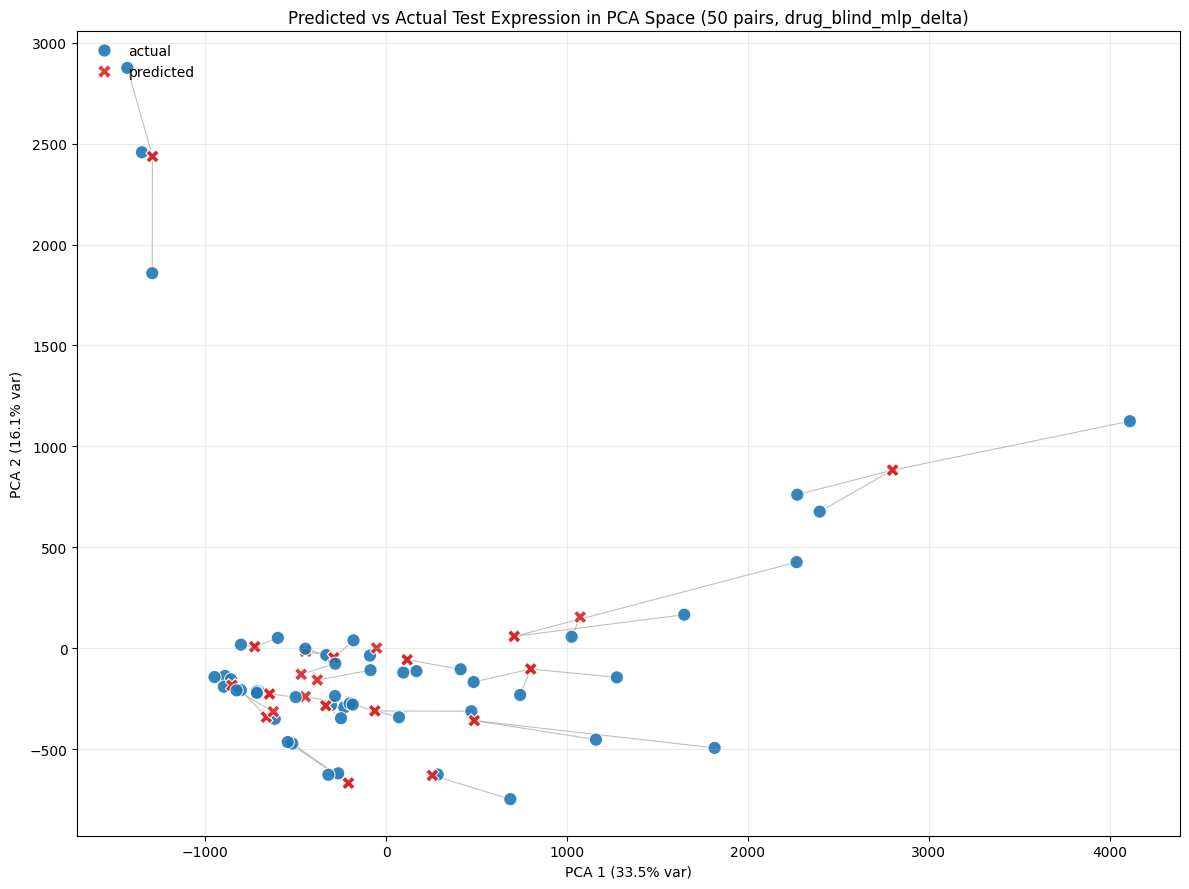

In [12]:
sampled_test_prediction_details_df = sample_prediction_details(
    prediction_details_df=test_prediction_details_df,
    sample_count=PLOT_TEST_SAMPLE_COUNT,
    sample_strategy=PLOT_TEST_SAMPLE_STRATEGY,
    random_seed=PLOT_RANDOM_SEED,
)
test_prediction_plot_df, sampled_test_pair_summary_df, test_embedding_explained_variance_ratio = build_prediction_pair_embedding(
    model=response_model,
    dataset=response_data_module.test_dataset,
    sampled_prediction_details_df=sampled_test_prediction_details_df,
    embedding_method=EMBEDDING_METHOD,
    n_components=N_EMBEDDING_COMPONENTS,
    random_seed=PLOT_RANDOM_SEED,
)

print(
    f"Plotted {len(sampled_test_prediction_details_df)} {PLOT_TEST_SAMPLE_STRATEGY} test pairs with {EMBEDDING_METHOD.upper()} using the best checkpoint."
)
display(sampled_test_pair_summary_df)

fig, ax = plt.subplots(figsize=(12, 9))
for pair_index, pair_points_df in test_prediction_plot_df.groupby("pair_index", sort=True):
    ordered_pair_points_df = pair_points_df.set_index("point_kind").loc[["actual", "predicted"]]
    ax.plot(
        ordered_pair_points_df["embedding_1"],
        ordered_pair_points_df["embedding_2"],
        color="#9e9e9e",
        linewidth=0.8,
        alpha=0.65,
        zorder=1,
    )

sns.scatterplot(
    data=test_prediction_plot_df,
    x="embedding_1",
    y="embedding_2",
    hue="point_kind",
    style="point_kind",
    palette={"actual": "#1f77b4", "predicted": "#d62728"},
    markers={"actual": "o", "predicted": "X"},
    s=90,
    alpha=0.9,
    ax=ax,
)
ax.set_title(
    f"Predicted vs Actual Test Expression in {EMBEDDING_METHOD.upper()} Space ({len(sampled_test_prediction_details_df)} pairs, {run_name})"
)
ax.set_xlabel(
    f"{EMBEDDING_METHOD.upper()} 1 ({test_embedding_explained_variance_ratio[0] * 100:.1f}% var)"
)
ax.set_ylabel(
    f"{EMBEDDING_METHOD.upper()} 2 ({test_embedding_explained_variance_ratio[1] * 100:.1f}% var)"
)
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


## Plot Test Cell-Line Accuracy


Computed test-set cell-line accuracy using mann_whitney_pvalue > 0.05 as the correctness rule.


,cell_line,n_test_samples,n_correct_predictions,cell_line_accuracy
0,CVCL_0152,111,83,0.747748
1,CVCL_0399,111,76,0.684685
2,CVCL_0334,111,73,0.657658
3,CVCL_0099,111,69,0.621622
4,CVCL_0320,111,69,0.621622
5,CVCL_0028,111,68,0.612613
6,CVCL_0371,111,66,0.594595
7,CVCL_0069,111,65,0.585586
8,CVCL_0218,111,65,0.585586
9,CVCL_0546,111,65,0.585586


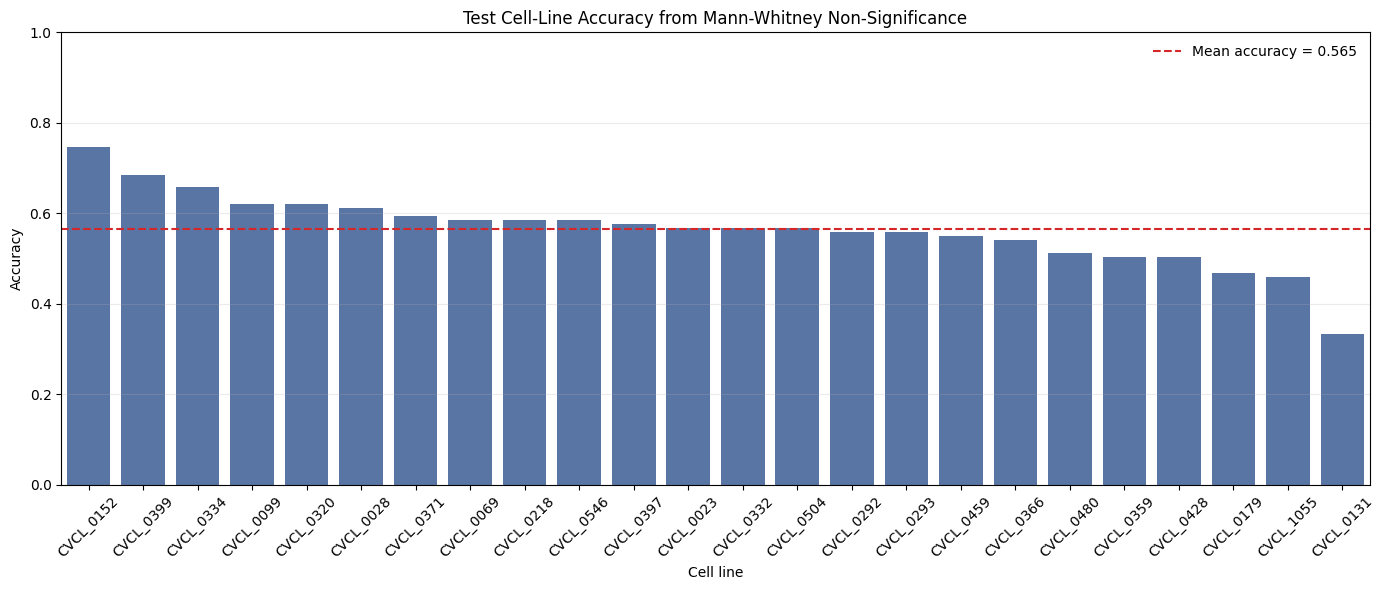

In [13]:
test_prediction_details_df = test_prediction_details_df.copy()
test_prediction_details_df["is_correct_prediction"] = test_prediction_details_df["mann_whitney_pvalue"] > 0.05

test_cell_line_accuracy_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        n_correct_predictions=("is_correct_prediction", "sum"),
    )
)
test_cell_line_accuracy_df["n_correct_predictions"] = test_cell_line_accuracy_df["n_correct_predictions"].astype(int)
test_cell_line_accuracy_df["cell_line_accuracy"] = (
    test_cell_line_accuracy_df["n_correct_predictions"] / test_cell_line_accuracy_df["n_test_samples"]
)
test_cell_line_accuracy_df = test_cell_line_accuracy_df.sort_values(
    ["cell_line_accuracy", "cell_line"],
    ascending=[False, True],
    ignore_index=True,
)
mean_cell_line_accuracy = float(test_cell_line_accuracy_df["cell_line_accuracy"].mean())

print("Computed test-set cell-line accuracy using mann_whitney_pvalue > 0.05 as the correctness rule.")
display(test_cell_line_accuracy_df)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=test_cell_line_accuracy_df,
    x="cell_line",
    y="cell_line_accuracy",
    color="#4c72b0",
    ax=ax,
)
ax.axhline(
    mean_cell_line_accuracy,
    color="#d62728",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean accuracy = {mean_cell_line_accuracy:.3f}",
)
ax.set_title("Test Cell-Line Accuracy from Mann-Whitney Non-Significance")
ax.set_xlabel("Cell line")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()


## Plot Test Cell-Line DEG Overlap Metrics


Computed test-set top-50 DEG overlap counts and signed nDCG@50 from predicted vs true delta expression.


,cell_line,n_test_samples,mean_top50_deg_match_count,median_top50_deg_match_count,min_top50_deg_match_count,max_top50_deg_match_count
0,CVCL_0293,111,25.729730,26.0,17.0,34.0
1,CVCL_0366,111,26.216216,26.0,18.0,34.0
2,CVCL_0131,111,24.612613,25.0,13.0,31.0
3,CVCL_0359,111,23.027027,23.0,12.0,30.0
4,CVCL_0332,111,22.144144,22.0,14.0,29.0
5,CVCL_1055,111,21.486486,22.0,11.0,30.0
6,CVCL_0023,111,21.828829,21.0,16.0,30.0
7,CVCL_0152,111,21.000000,21.0,16.0,27.0
8,CVCL_0179,111,20.144144,21.0,14.0,26.0
9,CVCL_0397,111,20.630631,21.0,11.0,31.0


,cell_line,n_test_samples,mean_signed_ndcg_at_50,median_signed_ndcg_at_50,min_signed_ndcg_at_50,max_signed_ndcg_at_50
0,CVCL_1055,111,0.603911,0.763814,0.012684,0.905548
1,CVCL_0293,111,0.649850,0.754098,0.013128,0.922554
2,CVCL_0131,111,0.626391,0.752551,0.096762,0.879531
3,CVCL_0366,111,0.568907,0.664113,0.098439,0.860755
4,CVCL_0332,111,0.544219,0.648753,0.055474,0.879810
5,CVCL_0359,111,0.544205,0.642383,0.074926,0.879365
6,CVCL_0480,111,0.516634,0.587519,0.102242,0.838062
7,CVCL_0320,111,0.499955,0.572281,0.024810,0.808574
8,CVCL_0023,111,0.533967,0.571500,0.109524,0.809906
9,CVCL_0371,111,0.465088,0.540211,0.051222,0.803698


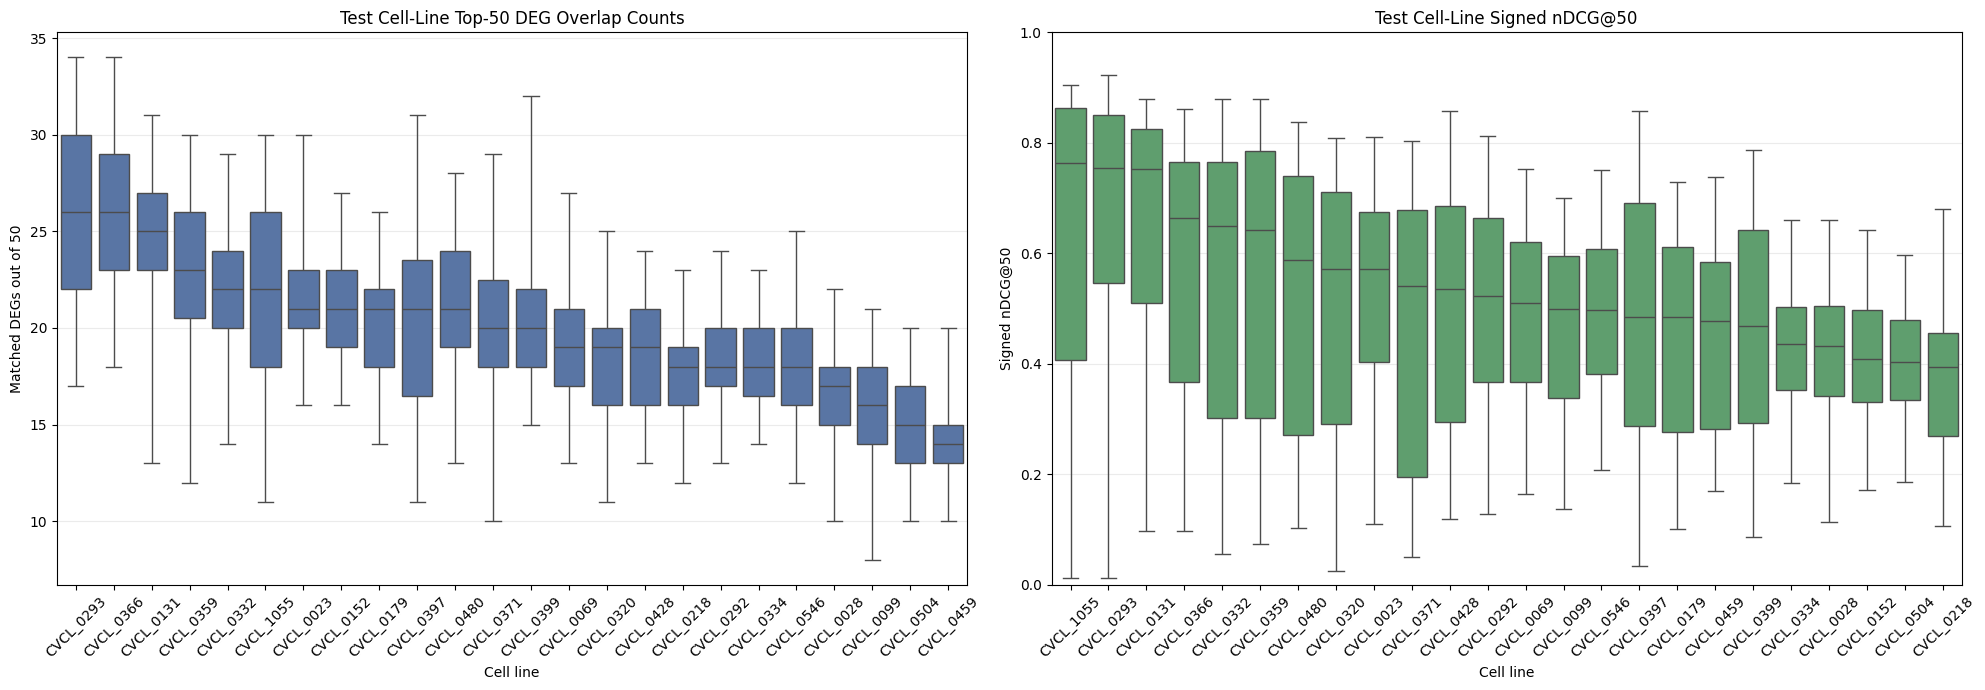

In [14]:
test_cell_line_deg_match_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        mean_top50_deg_match_count=("top50_deg_match_count", "mean"),
        median_top50_deg_match_count=("top50_deg_match_count", "median"),
        min_top50_deg_match_count=("top50_deg_match_count", "min"),
        max_top50_deg_match_count=("top50_deg_match_count", "max"),
    )
    .sort_values(["median_top50_deg_match_count", "cell_line"], ascending=[False, True], ignore_index=True)
)
test_cell_line_signed_ndcg_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        mean_signed_ndcg_at_50=("signed_ndcg_at_50", "mean"),
        median_signed_ndcg_at_50=("signed_ndcg_at_50", "median"),
        min_signed_ndcg_at_50=("signed_ndcg_at_50", "min"),
        max_signed_ndcg_at_50=("signed_ndcg_at_50", "max"),
    )
    .sort_values(["median_signed_ndcg_at_50", "cell_line"], ascending=[False, True], ignore_index=True)
)
deg_match_order = test_cell_line_deg_match_df["cell_line"].tolist()
signed_ndcg_order = test_cell_line_signed_ndcg_df["cell_line"].tolist()

print("Computed test-set top-50 DEG overlap counts and signed nDCG@50 from predicted vs true delta expression.")
display(test_cell_line_deg_match_df)
display(test_cell_line_signed_ndcg_df)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
deg_ax, ndcg_ax = axes

sns.boxplot(
    data=test_prediction_details_df,
    x="cell_line",
    y="top50_deg_match_count",
    order=deg_match_order,
    whis=(0, 100),
    color="#4c72b0",
    ax=deg_ax,
)
deg_ax.set_title("Test Cell-Line Top-50 DEG Overlap Counts")
deg_ax.set_xlabel("Cell line")
deg_ax.set_ylabel("Matched DEGs out of 50")
deg_ax.grid(True, axis="y", alpha=0.25)
deg_ax.tick_params(axis="x", rotation=45)

sns.boxplot(
    data=test_prediction_details_df,
    x="cell_line",
    y="signed_ndcg_at_50",
    order=signed_ndcg_order,
    whis=(0, 100),
    color="#55a868",
    ax=ndcg_ax,
)
ndcg_ax.set_title("Test Cell-Line Signed nDCG@50")
ndcg_ax.set_xlabel("Cell line")
ndcg_ax.set_ylabel("Signed nDCG@50")
ndcg_ax.set_ylim(0, 1)
ndcg_ax.grid(True, axis="y", alpha=0.25)
ndcg_ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()


In [ ]:
metric_artifact_paths = write_performance_metrics(
    Path(csv_logger.log_dir),
    {
        "evaluation_summary": evaluation_summary_df,
        "retrieval_summary": retrieval_summary_df,
        "test_prediction_details": test_prediction_details_df,
        "test_cell_line_accuracy": test_cell_line_accuracy_df,
        "test_cell_line_deg_match": test_cell_line_deg_match_df,
        "test_cell_line_signed_ndcg": test_cell_line_signed_ndcg_df,
    },
)

metric_artifact_paths